#### `④ 時間の可視化`

**「時間の経過とともにどのように変化するか？」**

**トレンド、増加・減少、季節性、周期性、変動を確認する。**

#### ※ 主なグラフ

- 折れ線グラフ
- 面グラフ
- 積み上げ面グラフ
- 時系列チャート

<div style="
    background-color:#232627;
    padding:10px 0;
    margin:12px 0;
    width:100%;
    font-family:Consolas, 'Yu Gothic', monospace;
    font-size:15px;
    line-height:1.5;
">

<div style="background-color:#2b2e2f; padding:5px 20px; white-space:pre;">売上</div>
<div style="background-color:#232627; padding:5px 20px; white-space:pre;"> ↑</div>
<div style="background-color:#2b2e2f; padding:5px 20px; white-space:pre;"> │             ／</div>
<div style="background-color:#232627; padding:5px 20px; white-space:pre;"> │        ／</div>
<div style="background-color:#2b2e2f; padding:5px 20px; white-space:pre;"> │     ／</div>
<div style="background-color:#232627; padding:5px 20px; white-space:pre;"> │  ／</div>
<div style="background-color:#2b2e2f; padding:5px 20px; white-space:pre;"> └────────────→ 時間</div>

</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# グラフで日本語が文字化けしないようにフォントを変更
plt.rcParams["font.family"] = "Yu Gothic"

# グラフで「-」記号が文字化けするのを防止
plt.rcParams["axes.unicode_minus"] = False

In [2]:
data = {
    "日付": [
        "2026-01-01", "2026-01-02", "2026-01-03", "2026-01-04", "2026-01-05",
        "2026-01-06", "2026-01-07", "2026-01-08", "2026-01-09", "2026-01-10",
        "2026-01-11", "2026-01-12", "2026-01-13", "2026-01-14", "2026-01-15"
    ],

    "販売量": [
        20, 25, 22, 30, 28,
        35, 32, 40, 38, 45,
        42, 48, 50, 46, 55
    ],

    "売上高": [
        200, 250, 220, 300, 280,
        350, 320, 400, 380, 450,
        420, 480, 500, 460, 550
    ],

    "純利益": [
        40, 50, 44, 60, 56,
        70, 64, 80, 76, 90,
        84, 96, 100, 92, 110
    ]
}

df = pd.DataFrame(data)

df.head()

,日付,販売量,売上高,純利益
0,2026-01-01,20,200,40
1,2026-01-02,25,250,50
2,2026-01-03,22,220,44
3,2026-01-04,30,300,60
4,2026-01-05,28,280,56


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   日付      15 non-null     str  
 1   販売量     15 non-null     int64
 2   売上高     15 non-null     int64
 3   純利益     15 non-null     int64
dtypes: int64(3), str(1)
memory usage: 612.0 bytes


In [4]:
# 時系列データでは、日付を文字列のままにせずdatetime型に変換
df["日付"] = pd.to_datetime(df["日付"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   日付      15 non-null     datetime64[us]
 1   販売量     15 non-null     int64         
 2   売上高     15 non-null     int64         
 3   純利益     15 non-null     int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 612.0 bytes


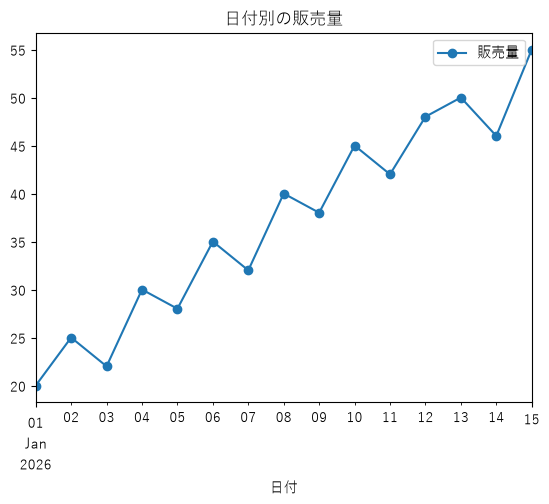

In [5]:
df.plot(
    x="日付",
    y="販売量",
    kind="line",
    marker="o",
    title="日付別の販売量"
);

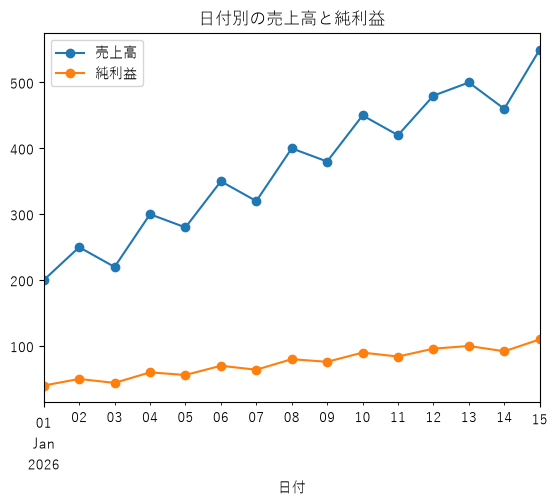

In [6]:
# 売上高 + 純利益
df.plot(
    x="日付",
    y=["売上高", "純利益"],
    kind="line",
    marker="o",
    title="日付別の売上高と純利益"
);

#### `⑤ 空間の可視化`

**「地域によってどのように異なるか？」**

- 地域別人口 → 地図上で地域ごとの人口規模を表現
- 地下鉄駅別の乗降者数 → 駅の位置に円を配置し、その大きさで表現

#### ※ 主な可視化

- コロプレスマップ（Choropleth）
- バブルマップ
- ドットマップ
- 等値線図
- カルトグラム


| **地図の可視化** | **主な表現** | **主に使用するデータ** | **どのような場合に使用するか** | **例** |
|---|---|---|---|---|
| `コロプレスマップ`（Choropleth） | **地域の色** | 地域別の数値 | 行政区域ごとの値を比較する場合 | 都道府県別人口、地域別失業率、投票率 |
| `バブルマップ`（Bubble Map） | **円の大きさ** | 位置ごとの数値 | 特定地点の値の大きさを比較する場合 | 駅別乗降者数、店舗別売上 |
| `ドットマップ`（Dot Map） | **点の数・位置** | 対象の位置・分布 | データがどこにどの程度分布しているか確認する場合 | 犯罪発生地点、病院の位置、人口分布 |
| `等値線図`（Isopleth / Contour Map） | **同じ値を結んだ線** | 連続的な空間データ | 値が空間的にどのように変化するか確認する場合 | 気温、気圧、降水量、標高 |
| `カルトグラム`（Cartogram） | **地域の大きさを変形** | 地域別の数値 | 実際の面積より特定の数値を強調する場合 | 人口に応じた地図、選挙の議席数 |

#### 1) `コロプレスマップ` → **色で表現**

地域ごとの値を**色の濃淡や色の違い**で表現する。

<img src="../images/image-14.png" width="1000">

#### 2) `バブルマップ` → **円の大きさで表現**

特定の位置に円を表示し、**値が大きいほど円を大きくする**。

<img src="../images/image-15.png" width="1000">

#### 3) `ドットマップ` → **点で表現**

点が多く集まっている地域ほど、**データが多く分布していることを表す**。

<img src="../images/image-16.png" width="1000">

#### 4) `等値線図` → **線で表現**

**同じ値を持つ地点を線で結ぶ。**

例：
- 気温
- 気圧
- 降水量
- 標高

<img src="../images/image-17.png" width="1000">

#### 5) `カルトグラム` → **地域の大きさを変形**

カルトグラムは、**データの値に応じて地域の実際の大きさや形を変形して表現する。**

<img src="../images/image-18.png" width="1000">